<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Personal Loan Campaign: Predicting Customer Loan Purchase Behavior</font></center>
<center><font size=6>UT Austin AIML Program — Machine Learning Classification Project</font></center>
<center><font size=6><b>Prepared by: Usiere Uko</b></font></center>

<div align="center">

<img src="https://images.pexels.com/photos/4386339/pexels-photo-4386339.jpeg?auto=compress&cs=tinysrgb&w=1200"
width="600"/>

</div>

## Problem Statement

AllLife Bank aims to increase adoption of its personal loan product among existing liability customers. Despite having a large customer base, only a relatively small proportion of customers currently accept personal loan offers.

The objective of this project is to build a machine learning model capable of predicting which customers are most likely to purchase a personal loan, while identifying the key customer attributes influencing loan acceptance.

## Objectives

- Predict whether a customer is likely to purchase a personal loan
- Identify the most influential variables driving loan acceptance
- Support targeted marketing and customer segmentation strategies
- Improve campaign efficiency and reduce acquisition costs

## Problem Definition

AllLife Bank seeks to improve the effectiveness of its personal loan marketing campaigns by identifying customers who are more likely to accept a personal loan offer.

The goal of this analysis is to develop a machine learning classification model that can accurately predict customer loan purchase behavior while uncovering the key financial and demographic factors influencing loan acceptance. The insights from this analysis can help the bank optimize marketing efforts, improve customer targeting, and increase conversion rates.

## Data Dictionary

The dataset includes customer demographic, financial, and banking relationship variables such as:

- Age and professional experience
- Annual income and mortgage value
- Family size and education level
- Credit card spending patterns
- Online banking and account usage
- Personal loan acceptance status (target variable)

## Importing necessary libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 63.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**:

1. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
Loan = pd.read_csv("/content/drive/MyDrive/Loan_Modelling.csv")

In [5]:
# creating a copy to avoid any changes to original data
data = Loan.copy()

## Data Overview

* Observations
* Sanity checks

### Viewing the first and last 5 rows of the dataset

In [6]:
# View the first 5 rows
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [7]:
# View the last 5 rows
data.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


*  There are three groups of customers based education which are levels (1) Undergrad, (2) Graduate and (3) Advanced/Professional
*  The ID column contains unique values






### Checking the shape of the dataset

In [8]:
# checking shape of the dataset
print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} columns.")

The dataset has 5000 rows and 14 columns.


### Checking the data types of the columns for the dataset.

In [9]:
# To view the data types in the dataset
data.dtypes

,0
ID,int64
Age,int64
Experience,int64
Income,int64
ZIPCode,int64
Family,int64
CCAvg,float64
Education,int64
Mortgage,int64
Personal_Loan,int64


* All columns are numeric in nature, 13 columns being integer type while one column is float data type



### Checking for missing values

In [10]:
# Display the number of missing values in each column
print("Number of missing values in each column:\n")
print(data.isnull().sum())

Number of missing values in each column:

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64


* There are no missing values in the dataset



### Checking for duplicate values

In [11]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

* There are no duplicate values in the data.

### Statistical summary of the data

In [12]:
# View statistical summary
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


* The average age is approximately 45 years, with values ranging from 23 to 67 years.
* Experience averages around 20 years, but the minimum value is -3, which is unrealistic and may indicate data entry or recording errors that require correction.
* The mean annual income is about 73,742, with a wide range between 8,000 and 224,000, showing significant variability among customers. The high standard deviation (46,000) suggests the presence of income outliers, likely representing a small group of very high earners.
* The average family size is about 2.4 members, with a range between 1 and 4.
* The mean CCAvg (average monthly credit card spending) is 1.94, with a maximum of 10.0, suggesting high variability in spending habits. This may also indicate potential outliers in spending behavior.
* Mortgage values vary widely (from 0 to 635), indicating that many customers have no mortgage, while others hold large mortgage loans.

## Exploratory Data Analysis.

# Univariate Analysis

In [13]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [14]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [15]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [16]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

##1. Distribution of the Mortgage Attribute

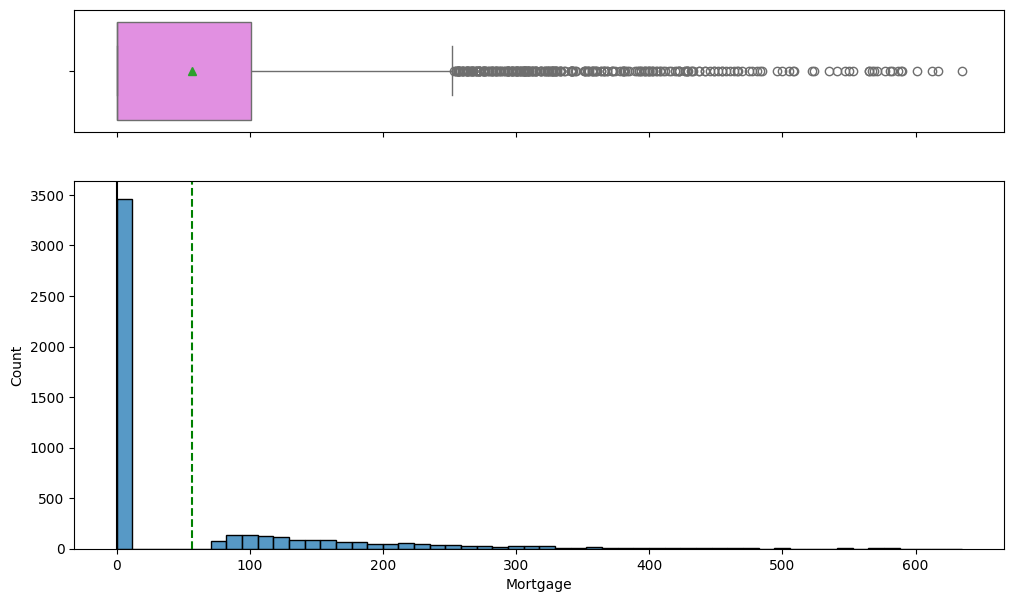

In [17]:
histogram_boxplot(data, "Mortgage")

* The Mortgage variable is highly right-skewed.
* Majority of customers have no mortgage.
* A small portion of customers have mortgages ranging from about 50k to over 600k.

Noticeable Patterns
* There is a significant concentration at zero, which stands out as a dominant cluster.
* The non-zero values are spread thinly and decrease in frequency as mortgage amounts increase.
* There appear to be a few outliers (mortgage values above ~$400k), indicating some customers with unusually high mortgage amounts.


## 2. Customers With Credit Cards

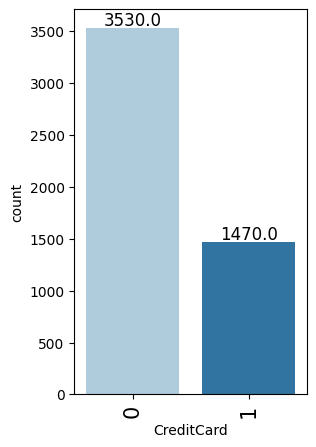

In [18]:
labeled_barplot(data, "CreditCard")

In [19]:
# checking the number of customers with credit cards
print(f"The number of customers with credit cards is {(data['CreditCard'] == 1).sum()}.")

The number of customers with credit cards is 1470.


* The number of customers with credit cards is 1470 while 3530 customers don't have credit cards



# Bivariate Analysis

In [20]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [21]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

## 3. Correlation of Attributes with Personal Loan

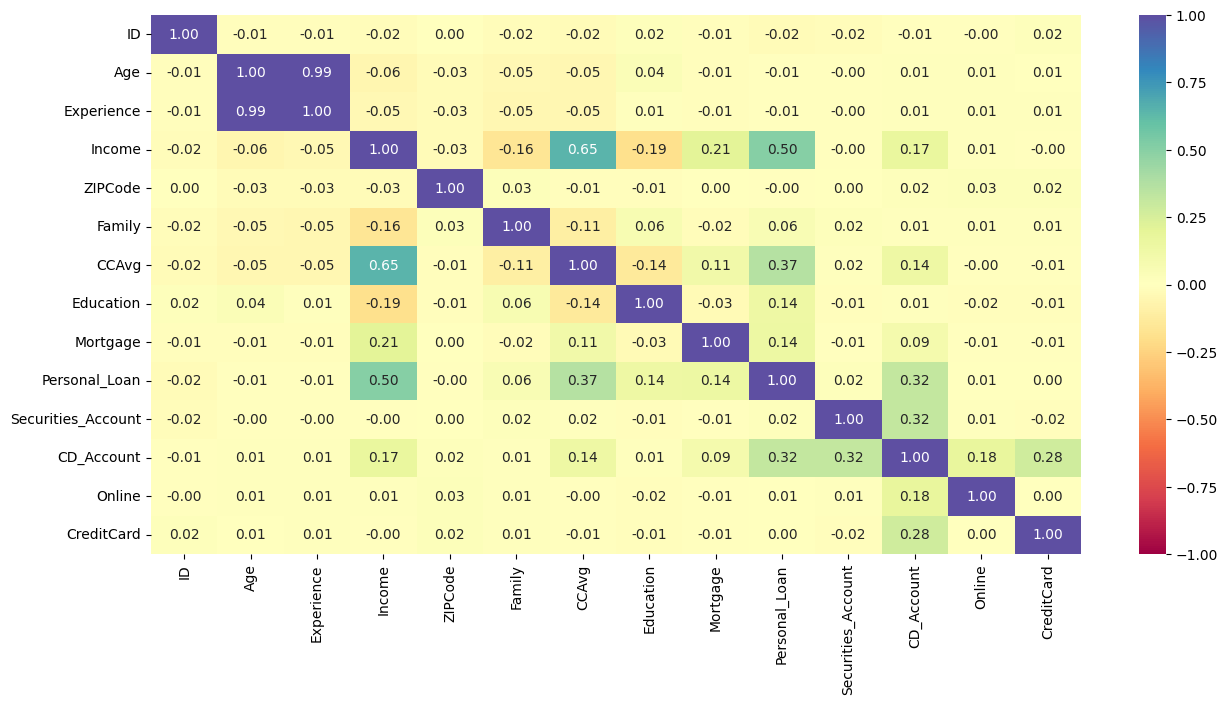

In [22]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* Annual income has the strongest correlation with customers who accepted personal loan offered in the last campaign (0.50), followed by average spending on credit cards (0.37) and customers with CD Accounts (0.32).
* We will analyze these correlations further.

## 4. Variation of Customer's Interest in Purchasing a Loan With their Age

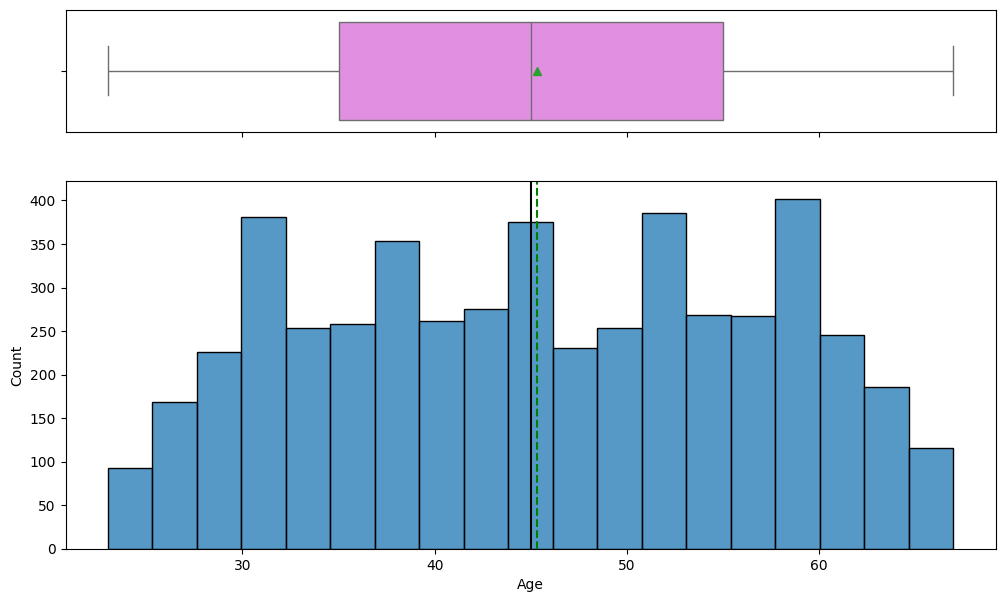

In [23]:
histogram_boxplot(data, "Age")

* The age distribution looks slightly left skewed with the median age around 45.
* Customer interest in purchasing a personal loan is highest among customers within the 30 - 32, 44 - 46, 52 - 54 and 58 - 60 years age bands. Customer interest in loan purchasing follows a lifecycle pattern, rising steeply after age 30 and remaining robust until the 60, a period defined by major financial goals and the highest overall economic contribution.
* There is no outlier present.


## 5. Variation of Customer's Interest in Purchasing a Loan With their Education

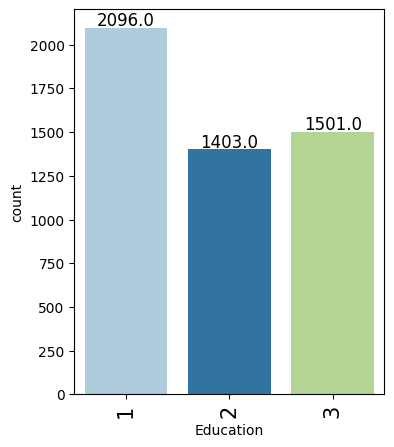

In [24]:
labeled_barplot(data, "Education")

* Interest in purchasing personal loans is highest among undergraduates (2,096), followed by professionals/holders of advanced degrees (1,501), with those holding master's degrees (1,403) showing the lowest interest.

## **Data Preprocessing**

* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

## Feature Engineering

* Feature engineering was not carried out in this analysis because the dataset provided by All Life Bank was already well-structured, clean, and contained clearly defined variables that were directly relevant to the prediction task.

## Outlier Detection

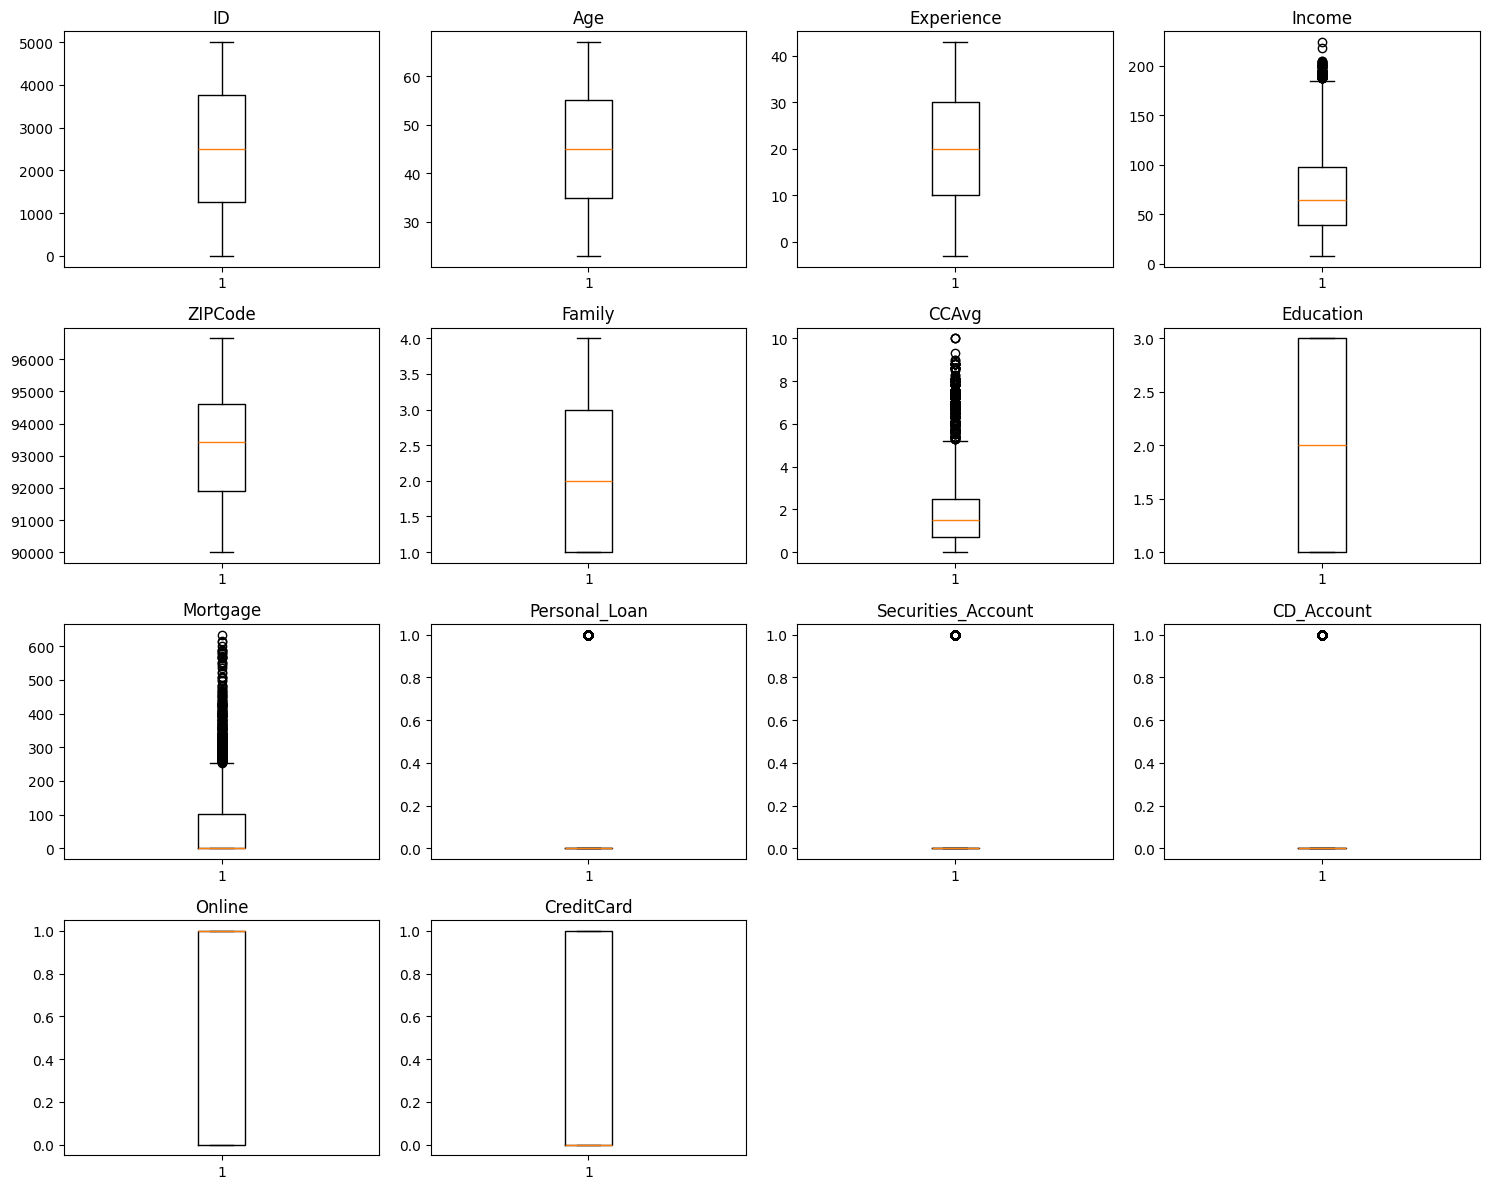

In [25]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

* There are quite a few outliers in the data.
* However, we will not treat them as they are proper values

## Data Treatment

*  The negative value (-3) detected in the Experience colum during Statistical Analysis was not treated due to the fact that Experience and  Personal Loan has almost zero correlation (-0.01).

## Data Preparation for Modeling

In [26]:
# Drop the 'ID' column as it is just an identifier and not useful for modeling
if 'ID' in data.columns:
    data.drop("ID", axis=1, inplace=True)

# Drop the 'Experience' column as it is perfectly correlated with Age
X = data.drop(["Personal_Loan", "Experience"], axis=1)
Y = data["Personal_Loan"]

X = pd.get_dummies(X, drop_first=True)

X = X.astype(float)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)


In [27]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3500, 11)
Shape of test set :  (1500, 11)
Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


* In the training set, around 90.6% did not take the personal loan offered  while 9.4% did. The ration is about the same in the test set (90% vs 10%).

## Model Building

### Model Evaluation Criterion

The model can make wrong predictions as:

* Predicting that a customer will not purchase a personal loan, but in reality, the customer would have purchased it (False Negative)
* Predicting that a customer will purchase a personal loan, but in reality, the customer will not purchase it (False Positive)

Which case is more important?

* If we predict that a customer will not purchase a loan but in reality, the customer would have, the bank loses a potential customer and the associated loan revenue opportunity.
* If we predict that a customer will purchase a loan but in reality, the customer will not, the bank wastes marketing efforts and resources trying to convert uninterested customers.
* However, the loss of a genuine potential customer (False Negative) is more costly than the marketing cost of a False Positive.

How to reduce the losses?

The bank would want the Recall to be maximized — the higher the recall score, the fewer genuine loan prospects are missed.
* The model_performance_classification_sklearn function will be used to check the model performance of models.
* The confusion_matrix_sklearnfunction will be used to plot confusion matrix.


In [28]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [29]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

# Decision Tree

In [30]:
model0 = DecisionTreeClassifier(random_state=1)
model0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

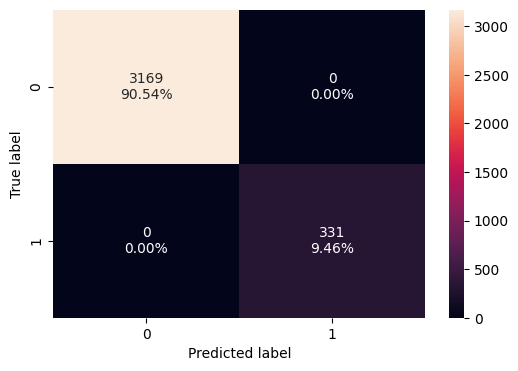

In [31]:
confusion_matrix_sklearn(model0, X_train, y_train)

In [32]:
decision_tree_default_perf_train = model_performance_classification_sklearn(
    model0, X_train, y_train
)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0



* The model has perfectly classified all training data (3171 customers who did not take the loan and 329 customers who did take the loan). There are zero false positives (FP) and zero false negatives (FN)
* It seems the model has overfitted the training data.

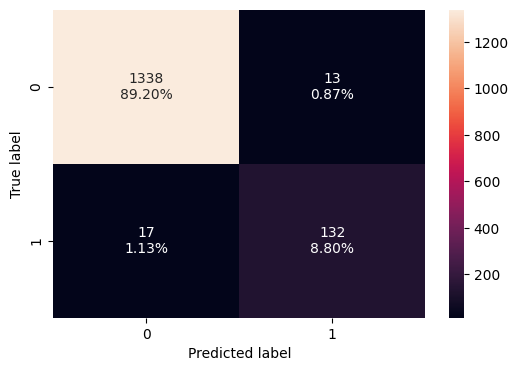

In [33]:
confusion_matrix_sklearn(model0, X_test, y_test)

In [34]:
decision_tree_default_perf_test = model_performance_classification_sklearn(
    model0, X_test, y_test
)
decision_tree_default_perf_test

,Accuracy,Recall,Precision,F1
0,0.98,0.885906,0.910345,0.897959


* The model performance on the test set dropped slightly to 98% with Recall at 88.5%, Precision at 91% and F1 at 89.8%. The decision tree model performs well with a high accuracy, strong recall and balanced F1 score.
* In order to maximize the recall score and reduce false negatives, we will perform further pruning and hyperparameter tuning to improve the model’s overall performance and generalization.




## Model Performance Improvement

### Decision Tree (Pre-pruning)

In [35]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=42
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 2
Max leaf nodes: 50
Min samples split: 10
Best test recall score: 1.0


In [36]:
# creating an instance of the best model
model2 = best_estimator

# fitting the best model to the training data
model2.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(2),
                       max_leaf_nodes=50, min_samples_split=10,
                       random_state=42)

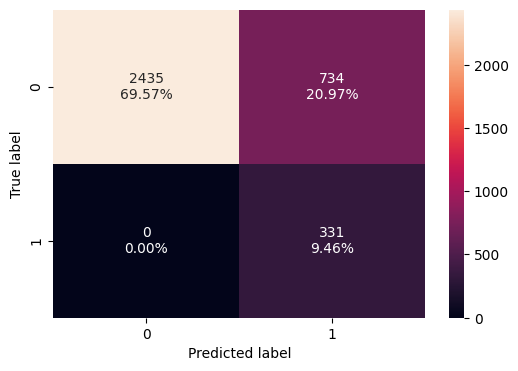

In [37]:
confusion_matrix_sklearn(model2, X_train, y_train)

In [38]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    model2, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.790286,1.0,0.310798,0.474212


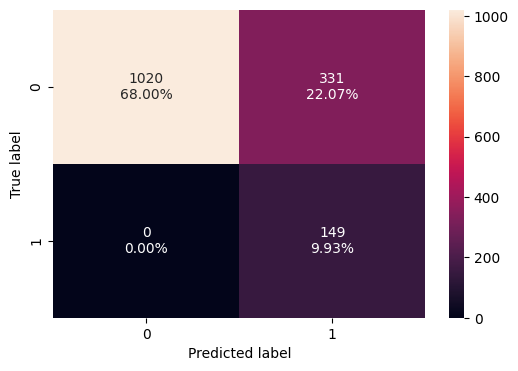

In [39]:
confusion_matrix_sklearn(model2, X_test, y_test)

In [40]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    model2, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.779333,1.0,0.310417,0.473768


* The model has achieved a recall of 100%, but lower accuracy (78%) and F1 score of 47% on test data. The model is biased towards predicting loan approval which maximizes recall and reduces reliability.
* Further fine-tuning of pruning parameters may help balance recall and precision for better overall performance.

In [41]:
feature_names = list(X_train.columns)
importances = model2.feature_importances_
indices = np.argsort(importances)

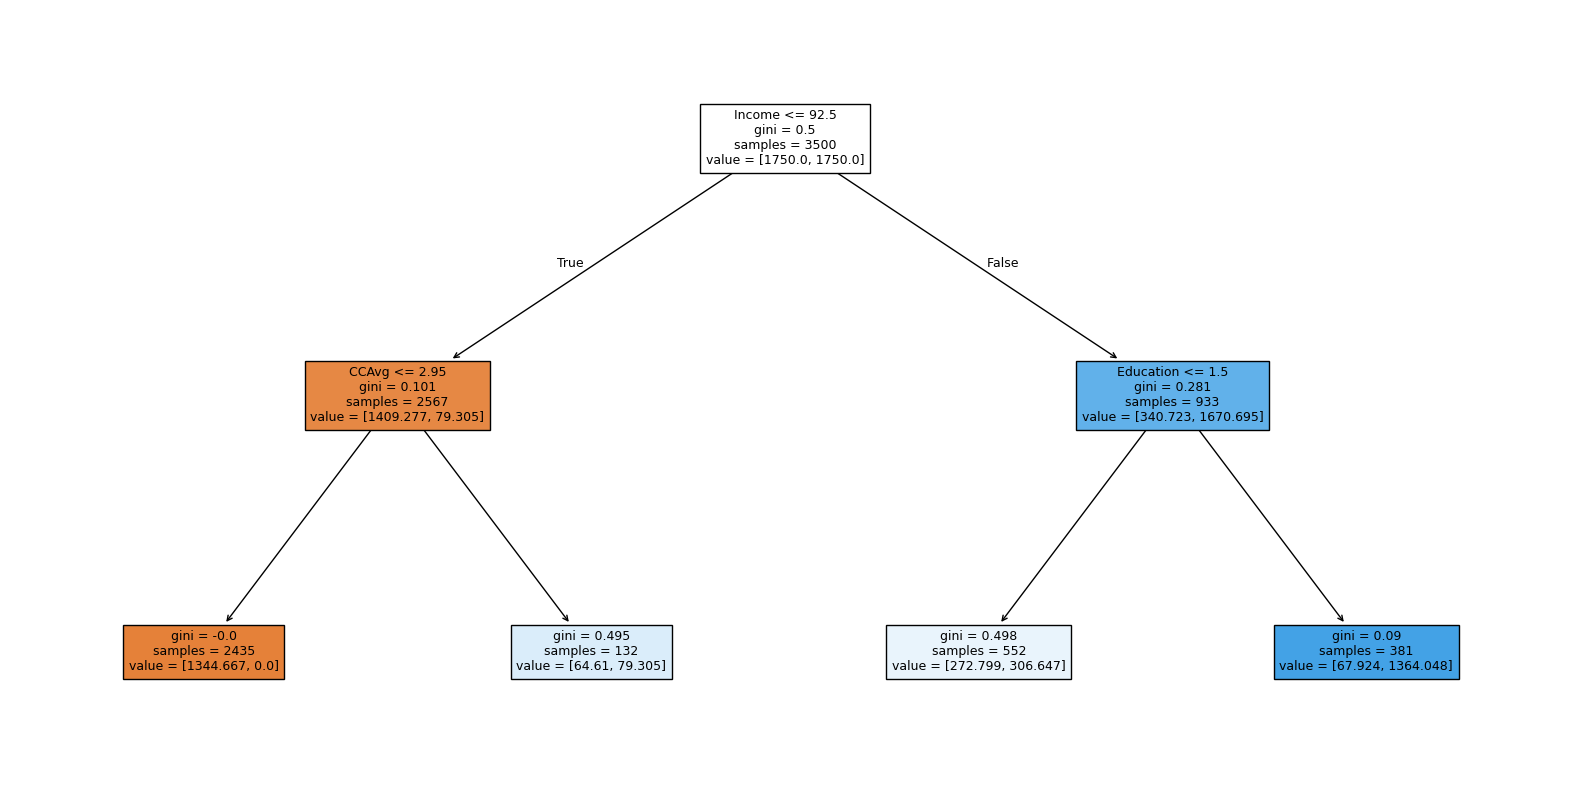

In [42]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    model2,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [43]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model2, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- weights: [64.61, 79.31] class: 1
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- weights: [272.80, 306.65] class: 1
|   |--- Education >  1.50
|   |   |--- weights: [67.92, 1364.05] class: 1



* If annual income (Income) is less than or equal to 92.5k, average spending on credit cards per month (CCAvg) is less than 2.95k, then the customer is most likely to decline the personal loan offered.
* If annual income (Income) is more than 92.5k, education is less than or equal to 1.5 (an undergraduate, with a significant number holding graduate degrees), then the customer is most likely to accept the personal loan offered.



In [44]:
importances = model2.feature_importances_
importances

array([0.        , 0.82007181, 0.        , 0.        , 0.06262835,
       0.11729984, 0.        , 0.        , 0.        , 0.        ,
       0.        ])

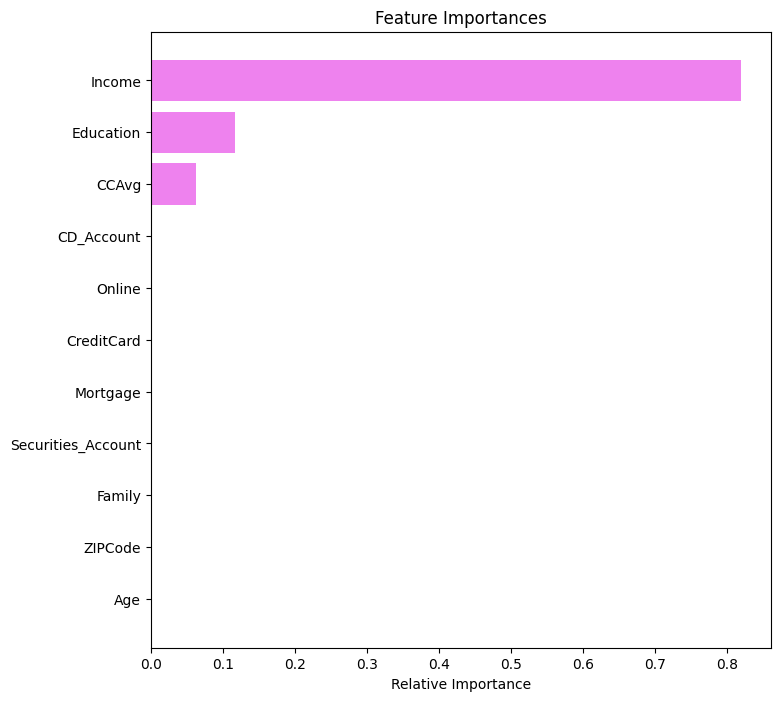

In [45]:
# importance of features in the tree building

importances = model2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* In the pre-pruned decision tree, Income, Education and CCAvg are the most important features.


### Decision Tree (Post pruning)

In [46]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [47]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-8.696553e-15
1,4.729571e-19,-8.696080e-15
2,4.729571e-19,-8.695607e-15
3,4.729571e-19,-8.695134e-15
4,5.255079e-19,-8.694609e-15
5,1.051016e-18,-8.693558e-15
6,8.338059e-18,-8.685220e-15
7,1.257806e-17,-8.672642e-15
8,1.545500e-04,3.090999e-04
9,1.561475e-04,6.213950e-04


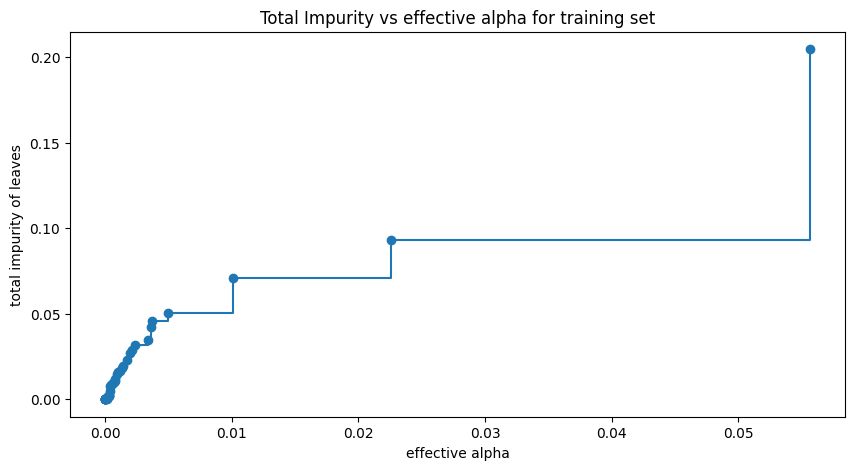

In [48]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

Training the decision tree using the effective alphas.

In [49]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.29537927599923197


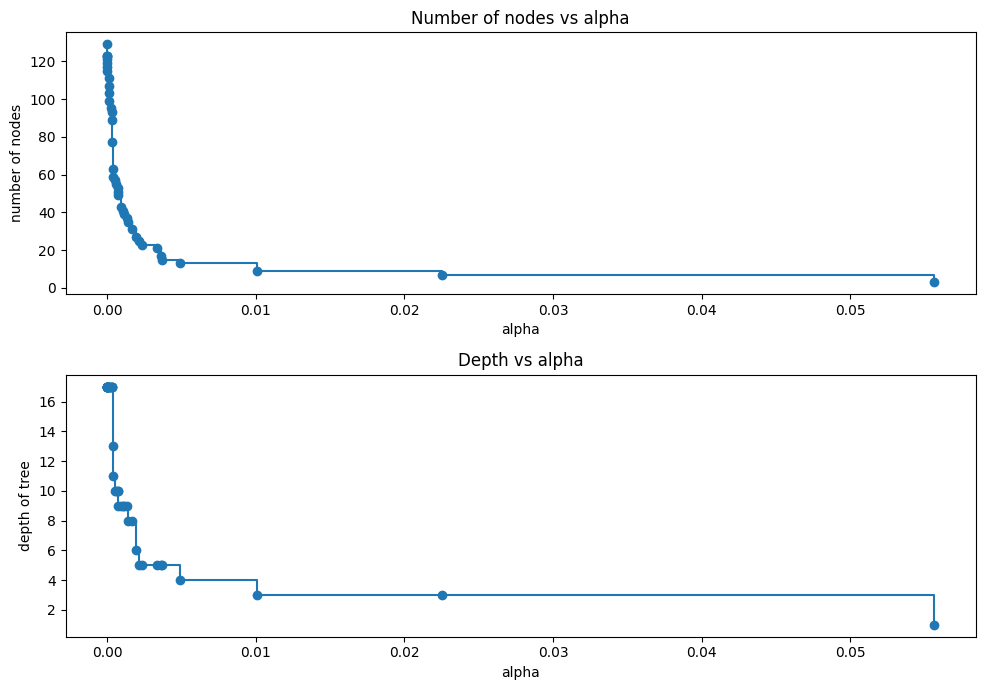

In [50]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [51]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [52]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

In [53]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

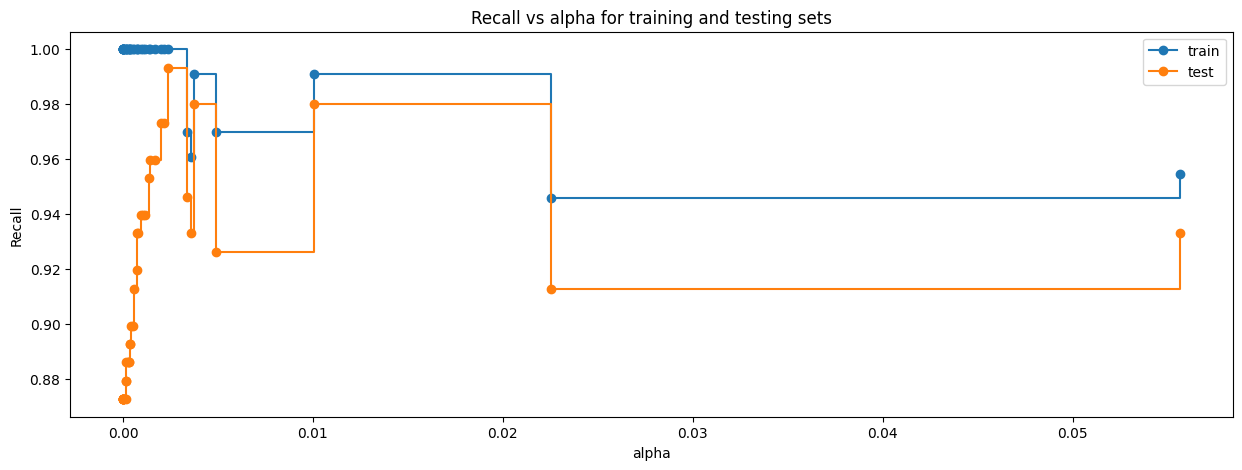

In [54]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [55]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0023758086197746466),
                       class_weight='balanced', random_state=1)


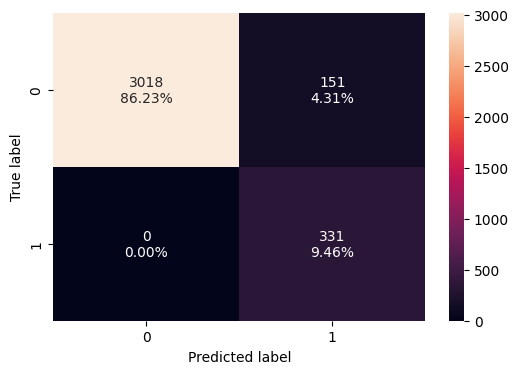

In [56]:
model4 = best_model
confusion_matrix_sklearn(model4, X_train, y_train)

In [57]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    model4, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.956857,1.0,0.686722,0.814268


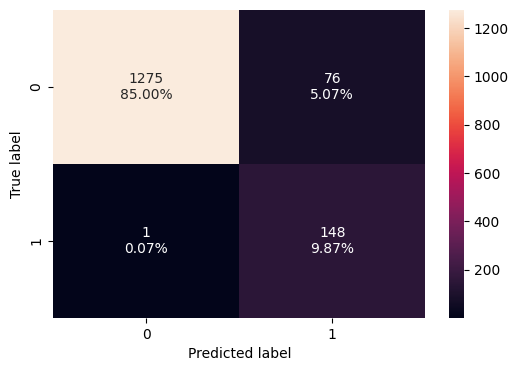

In [58]:
confusion_matrix_sklearn(model4, X_test, y_test)

In [59]:
decision_tree_post_test = model_performance_classification_sklearn(
    model4, X_test, y_test
)
decision_tree_post_test

,Accuracy,Recall,Precision,F1
0,0.948667,0.993289,0.660714,0.793566




* The model has accuracy of 95%, high recall of 99% and a moderate precision of 66% and F1 score of 79%.
* The pruned model performs robustly with high recall and balanced accuracy, making it effective for identifying potential loan customers while maintaining generalization across unseen data.

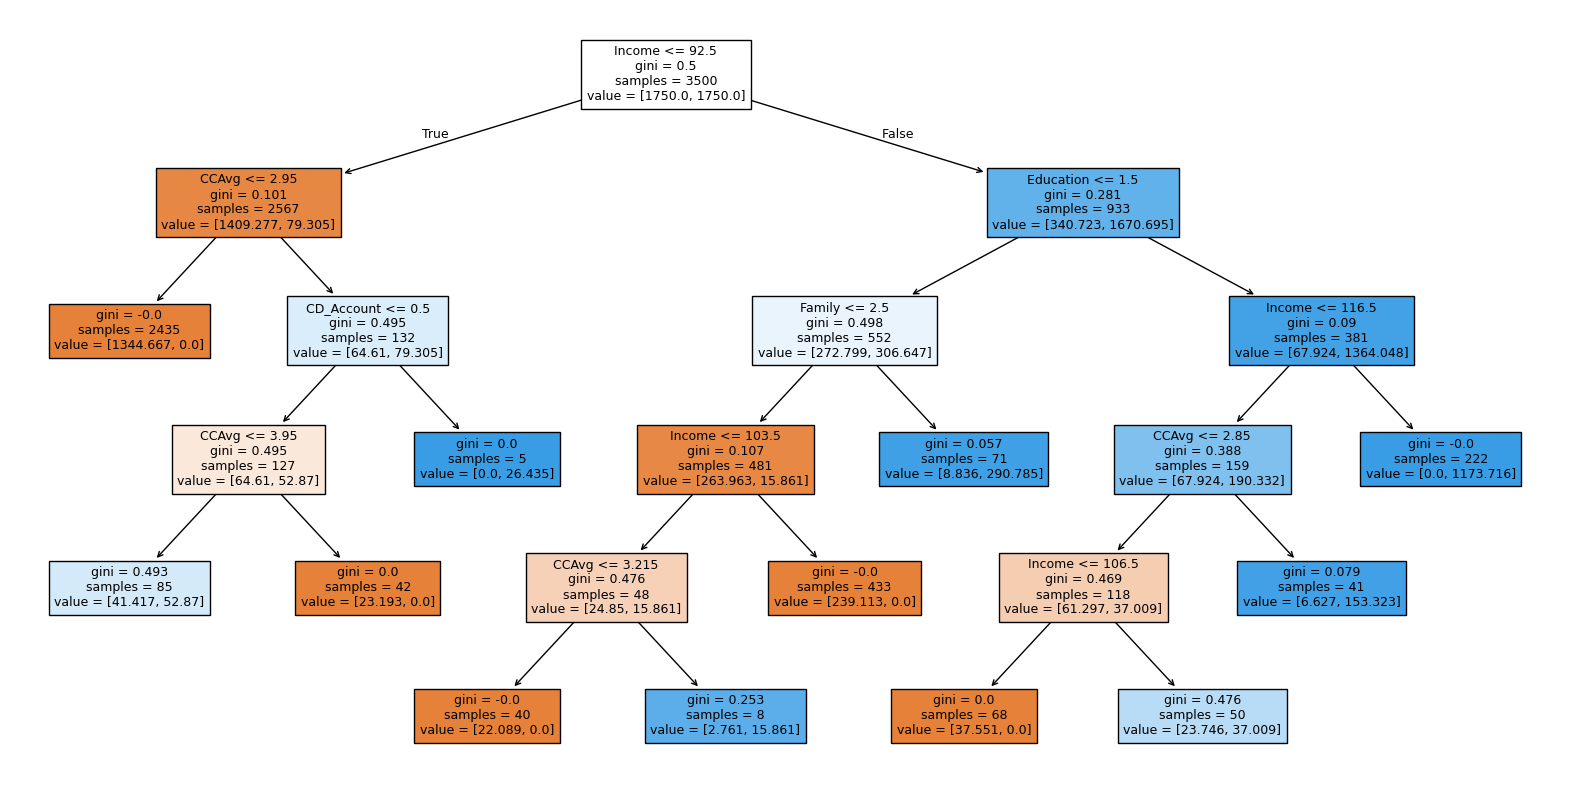

In [60]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    model4,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [61]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model4, feature_names=feature_names, show_weights=True))


|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- CCAvg <= 3.95
|   |   |   |   |--- weights: [41.42, 52.87] class: 1
|   |   |   |--- CCAvg >  3.95
|   |   |   |   |--- weights: [23.19, 0.00] class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- weights: [0.00, 26.44] class: 1
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- Income <= 103.50
|   |   |   |   |--- CCAvg <= 3.21
|   |   |   |   |   |--- weights: [22.09, 0.00] class: 0
|   |   |   |   |--- CCAvg >  3.21
|   |   |   |   |   |--- weights: [2.76, 15.86] class: 1
|   |   |   |--- Income >  103.50
|   |   |   |   |--- weights: [239.11, 0.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- weights: [8.84, 290.79] class: 1
|   |--- Education >  1.50
|   |   |--- Income <= 116.50
|   |   |   |--- CCAvg <= 2.85
|   |   |   |   |--- Income <= 106.50
|   |   |   |   | 

* As in the pre-pruned tree, if annual income (Income) is less than or equal to 92.5k, average spending on credit cards per month (CCAvg) is less than 2.95k, then the customer is most likely to decline the personal loan offered.


In [62]:
importances = model4.feature_importances_
indices = np.argsort(importances)

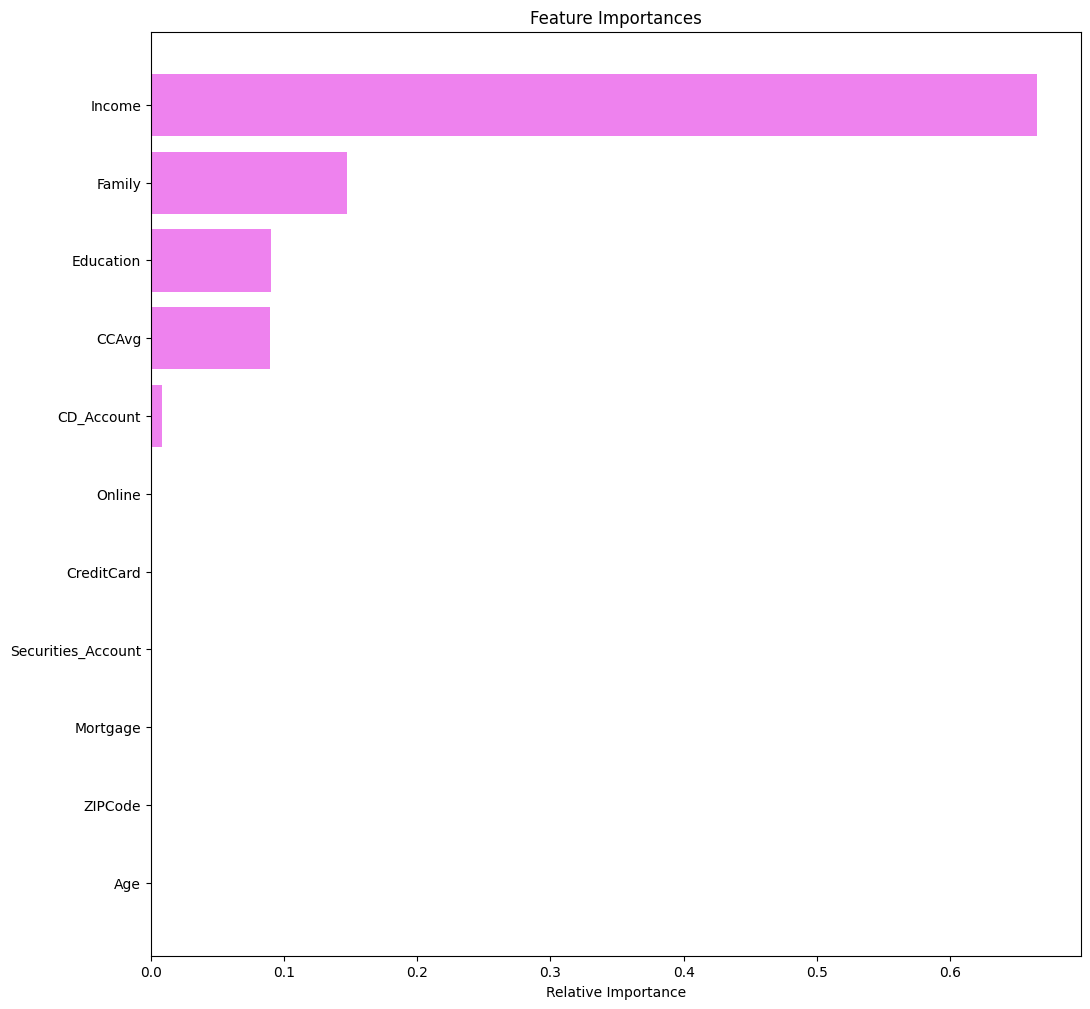

In [63]:
plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* In the post pruned tree, the most important features are Income and Family.

## Model Performance Comparison and Final Model Selection

In [65]:
model1 = DecisionTreeClassifier(random_state=1, class_weight='balanced')
model1.fit(X_train, y_train)

decision_tree_perf_train = model_performance_classification_sklearn(model1, X_train, y_train)

# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_train.T,
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,1.0,0.790286,0.956857
Recall,1.0,1.0,1.000000,1.000000
Precision,1.0,1.0,0.310798,0.686722
F1,1.0,1.0,0.474212,0.814268


In [67]:
decision_tree_perf_test = model_performance_classification_sklearn(model1, X_test, y_test)

# testing performance comparison

models_test_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.980000,0.974667,0.779333,0.948667
Recall,0.885906,0.872483,1.000000,0.993289
Precision,0.910345,0.872483,0.310417,0.660714
F1,0.897959,0.872483,0.473768,0.793566


* Decision tree models with post-pruning is giving much better recall scores on both training and test sets. The same is applcable to accuracy, precision and F1 scores.
* Therefore, we are choosing the post-pruned tree as our best model.

# Actionable Insights and Business Recommendations for All Life Bank


## Actionable Insights

- The post-pruning model demonstrated strong performance, achieving high recall while maintaining stable generalization across datasets.

- Income, average credit card spending (CCAvg), and CD account ownership were identified as key drivers influencing personal loan acceptance.

- Customers with higher income levels, active credit usage, and stronger banking relationships showed a greater likelihood of accepting personal loan offers.

## Recommendations

- Use the model to support targeted marketing campaigns focused on high-potential customers.

- Prioritize customers with higher income, strong credit card activity, and existing banking relationships for personalized loan offers.

- Integrate the predictive model into marketing workflows to improve campaign efficiency and reduce missed opportunities.

- Continuously retrain and validate the model using updated customer data to maintain performance over time.

___